# Prompt-generation dissociation

Per-pair gaps in linear probing R² (prompt and generation stages) plotted
against the geometric gap (Δρ⟂ᴰ). The two metrics disagree: probing alone
misses what the trajectory geometry picks up.

In [1]:
import os
from pathlib import Path

_root = Path.cwd()
while not (_root / 'pyproject.toml').exists() and _root.parent != _root:
    _root = _root.parent
os.chdir(_root)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA = Path('data/processed')
OUT_FIGS = Path('figures')
OUT_FIGS.mkdir(parents=True, exist_ok=True)

DOMAIN_ORDER = ['code', 'math', 'sat']
DOMAIN_LABEL = {'code': 'Code', 'math': 'Math', 'sat': 'SAT'}
PAPER_LABEL = {
    'deepseek-r1-7b': 'DS-R1-7B', 'deepseek-r1-14b': 'DS-R1-14B',
    'deepseek-r1-32b': 'DS-R1-32B', 'qwq-32b': 'QwQ-32B',
    'r1-distill-llama-8b': 'R1-Llama-8B', 'phi-4-reasoning': 'Phi-4-R',
    'qwen-7b': 'Qwen-7B', 'qwen-14b': 'Qwen-14B', 'qwen-32b': 'Qwen-32B',
    'llama-8b': 'Llama-8B', 'phi-4': 'Phi-4',
}
REASONING_ORDER = ['deepseek-r1-7b', 'deepseek-r1-14b', 'deepseek-r1-32b',
                   'qwq-32b', 'r1-distill-llama-8b', 'phi-4-reasoning']
BASELINE_ORDER = ['qwen-7b', 'qwen-14b', 'qwen-32b', 'llama-8b', 'phi-4']
MODEL_ORDER = REASONING_ORDER + BASELINE_ORDER
PAPER_LABELS = [PAPER_LABEL[m] for m in MODEL_ORDER]


## Generate analysis inputs

Regenerates `data/processed/04_probing_aggregated.parquet` and
`data/processed/04_dissociation.parquet` from per-model probing files when
`IRT_RESULTS_ROOT` is set.


In [2]:
# >>> generation-marker <<<
RESULTS = Path(os.environ.get('IRT_RESULTS_ROOT', 'data/results'))
PROCESSED = Path('data/processed')
REGEN = RESULTS.exists() and any(RESULTS.rglob('probing/prompt_stage_probes_pooled.parquet'))
print(f'regenerate from raw? {REGEN}  (IRT_RESULTS_ROOT={RESULTS})')


regenerate from raw? False  (IRT_RESULTS_ROOT=data/results)


### Aggregate probing parquets (prompt + generation + length)


In [3]:
# Concatenate per-model probing parquets across 11 hidden-state models x 3 domains.
HIDDEN_STATE_MODELS = ['deepseek-r1-7b', 'deepseek-r1-14b', 'deepseek-r1-32b',
                      'r1-distill-llama-8b', 'qwq-32b', 'phi-4-reasoning',
                      'qwen-7b', 'qwen-14b', 'qwen-32b', 'llama-8b', 'phi-4']
STAGES = {'prompt': 'prompt_stage_probes_pooled.parquet',
          'generation': 'generation_heatmap_pooled.parquet',
          'length': 'length_probes.parquet'}

if REGEN:
    frames = []
    for model in HIDDEN_STATE_MODELS:
        for dom in DOMAIN_ORDER:
            for stage, fname in STAGES.items():
                p = RESULTS / dom / model / 'probing' / fname
                if not p.exists():
                    continue
                df = pd.read_parquet(p)
                df.insert(0, 'stage', stage)
                df.insert(0, 'domain', dom)
                df.insert(0, 'model_id', model)
                frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out.to_parquet(PROCESSED / '04_probing_aggregated.parquet', index=False)
    print(f'rebuilt 04_probing_aggregated.parquet ({len(out):,} rows)')
else:
    print('using shipped 04_probing_aggregated.parquet')


using shipped 04_probing_aggregated.parquet


### Derive per-pair dissociation values from probing + per-pair correlations


In [4]:
# Per-pair Delta R^2 (prompt and generation stages) and Delta rho_perp.
# Recomputed every run from the two shipped caches (probing R^2 + the median-across-layers
# rho_perp) so the dissociation stays consistent with notebook 02 without the raw results tree.
PAIRS = [
    ('Qwen-7B',   'deepseek-r1-7b',         'qwen-7b'),
    ('Qwen-14B',  'deepseek-r1-14b',        'qwen-14b'),
    ('Qwen-32B',  'deepseek-r1-32b',        'qwen-32b'),
    ('QwQ-32B',   'qwq-32b',                'qwen-32b'),
    ('Llama-8B',  'r1-distill-llama-8b',    'llama-8b'),
    ('Phi-4',     'phi-4-reasoning',        'phi-4'),
]

probes = pd.read_parquet(PROCESSED / '04_probing_aggregated.parquet')
corrs = pd.read_parquet(PROCESSED / '02_per_pair_correlations.parquet')
peak_r2 = (probes[probes['stage'].isin(['prompt', 'generation'])]
           .groupby(['model_id', 'domain', 'stage'])['r2_mean'].max()
           .reset_index())
peak_pivot = peak_r2.pivot_table(index=['model_id', 'domain'], columns='stage', values='r2_mean')
rho_D = corrs[corrs['metric'] == 'D'].set_index(['model', 'domain'])['rho_perp']
rows = []
for pair_name, r1_model, base_model in PAIRS:
    for dom in DOMAIN_ORDER:
        try:
            r2_r1 = float(peak_pivot.loc[(r1_model, dom), 'prompt'])
            r2_b  = float(peak_pivot.loc[(base_model, dom), 'prompt'])
            r2g_r1 = float(peak_pivot.loc[(r1_model, dom), 'generation'])
            r2g_b  = float(peak_pivot.loc[(base_model, dom), 'generation'])
            rho_r1 = float(rho_D.loc[(r1_model, dom)])
            rho_b  = float(rho_D.loc[(base_model, dom)])
        except KeyError:
            continue
        rows.append({
            'pair': pair_name, 'domain': dom,
            'r1_model': r1_model, 'base_model': base_model,
            'r2_r1': r2_r1, 'r2_base': r2_b, 'delta_r2': r2_r1 - r2_b,
            'r2_gen_r1': r2g_r1, 'r2_gen_base': r2g_b, 'delta_r2_gen': r2g_r1 - r2g_b,
            'rho_perp_D_r1': rho_r1, 'rho_perp_D_base': rho_b,
            'delta_rho_perp_D': rho_r1 - rho_b,
            'is_labeled': False,
        })
pd.DataFrame(rows).to_parquet(PROCESSED / '04_dissociation.parquet', index=False)
print(f'recomputed 04_dissociation.parquet ({len(rows)} rows) from 04_probing_aggregated + 02_per_pair_correlations')

recomputed 04_dissociation.parquet (18 rows) from 04_probing_aggregated + 02_per_pair_correlations


---


## Per-pair table


In [5]:
df = pd.read_parquet(DATA / '04_dissociation.parquet')
print(df.round(3).sort_values(['domain', 'pair']).to_string(index=False))


    pair domain            r1_model base_model  r2_r1  r2_base  delta_r2  r2_gen_r1  r2_gen_base  delta_r2_gen  rho_perp_D_r1  rho_perp_D_base  delta_rho_perp_D  is_labeled
Llama-8B   code r1-distill-llama-8b   llama-8b  0.191    0.192    -0.000      0.224        0.370        -0.146          0.356            0.051             0.305       False
   Phi-4   code     phi-4-reasoning      phi-4  0.241    0.336    -0.095      0.384        0.523        -0.140          0.275           -0.015             0.290       False
 QwQ-32B   code             qwq-32b   qwen-32b  0.234    0.233     0.002      0.372        0.389        -0.017          0.417           -0.098             0.515       False
Qwen-14B   code     deepseek-r1-14b   qwen-14b  0.232    0.211     0.021      0.306        0.407        -0.101          0.456           -0.042             0.499       False
Qwen-32B   code     deepseek-r1-32b   qwen-32b  0.227    0.233    -0.005      0.359        0.389        -0.031          0.401          

## Dissociation figure (`prompt_generation_dissociation.pdf`)


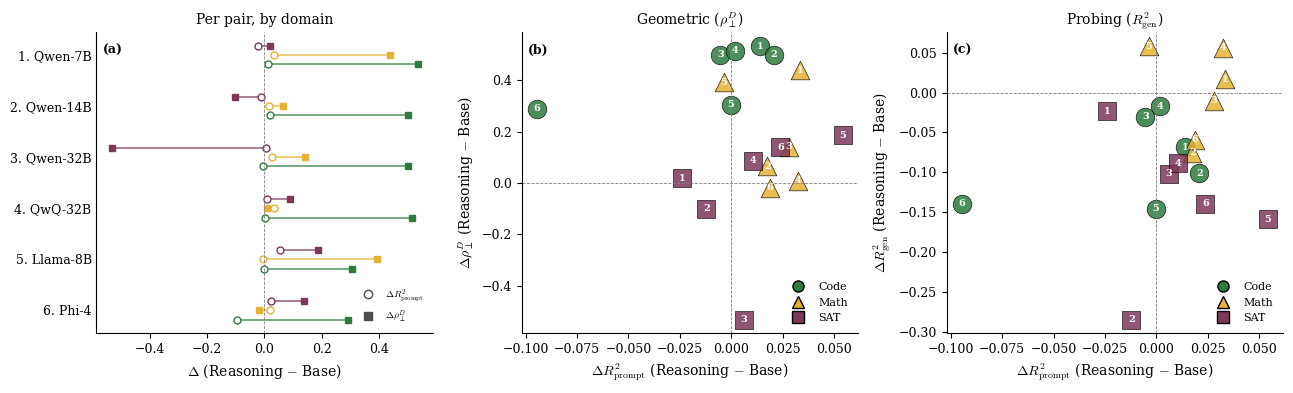

In [6]:
PAIR_ORDER = ['Qwen-7B', 'Qwen-14B', 'Qwen-32B', 'QwQ-32B', 'Llama-8B', 'Phi-4']
PAIR_NUM = {p: i + 1 for i, p in enumerate(PAIR_ORDER)}
DOMAIN_MARKER = {'code': ('o', '#2E7B3F'), 'math': ('^', '#E5B233'), 'sat': ('s', '#7D3759')}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))

# Panel (a): dumbbell per pair
ax = axes[0]
for i, p in enumerate(PAIR_ORDER):
    sub = df[df['pair'] == p]
    for j, (_, row) in enumerate(sub.iterrows()):
        marker, colour = DOMAIN_MARKER[row['domain']]
        y = len(PAIR_ORDER) - 1 - i + (j - 1) * 0.18
        ax.plot([row['delta_r2'], row['delta_rho_perp_D']], [y, y], '-', color=colour, lw=1.2, alpha=0.75)
        ax.plot(row['delta_r2'], y, 'o', mfc='white', mec=colour, ms=5)
        ax.plot(row['delta_rho_perp_D'], y, 's', mfc=colour, mec=colour, ms=5)
ax.axvline(0, color='0.5', ls='--', lw=0.6)
ax.set_yticks(range(len(PAIR_ORDER) - 1, -1, -1))
ax.set_yticklabels([f'{PAIR_NUM[p]}. {p}' for p in PAIR_ORDER])
ax.tick_params(axis='y', length=0)
ax.set_xlabel(r'$\Delta$ (Reasoning $-$ Base)')
ax.set_title('Per pair, by domain', fontsize=10)
ax.text(0.02, 0.96, '(a)', transform=ax.transAxes, fontweight='bold', va='top')
# inline legend (markers)
marker_handles = [
    plt.Line2D([0], [0], marker='o', mfc='white', mec='0.3', ls='', ms=6,
               label=r'$\Delta R^2_{\mathrm{prompt}}$'),
    plt.Line2D([0], [0], marker='s', mfc='0.3', mec='0.3', ls='', ms=6,
               label=r'$\Delta \rho_{\perp}^{D}$'),
]
ax.legend(handles=marker_handles, loc='lower right', fontsize=7, frameon=False)

# Panel (b): scatter Delta R^2 prompt vs Delta rho_perp_D
ax = axes[1]
for dom, (marker, colour) in DOMAIN_MARKER.items():
    sub = df[df['domain'] == dom]
    for _, row in sub.iterrows():
        n = PAIR_NUM[row['pair']]
        ax.scatter(row['delta_r2'], row['delta_rho_perp_D'], marker=marker, c=colour, edgecolor='black',
                   s=180, lw=0.5, alpha=0.85)
        ax.text(row['delta_r2'], row['delta_rho_perp_D'], str(n), ha='center', va='center',
                color='white', fontsize=7, fontweight='bold')
ax.axhline(0, color='0.5', ls='--', lw=0.6)
ax.axvline(0, color='0.5', ls='--', lw=0.6)
ax.set_xlabel(r'$\Delta R^2_{\mathrm{prompt}}$ (Reasoning $-$ Base)')
ax.set_ylabel(r'$\Delta \rho_{\perp}^{D}$ (Reasoning $-$ Base)')
ax.set_title(r'Geometric ($\rho_{\perp}^{D}$)', fontsize=10)
ax.text(0.02, 0.96, '(b)', transform=ax.transAxes, fontweight='bold', va='top')
dom_handles = [plt.Line2D([0], [0], marker=m, mfc=c, mec='black', ls='', ms=8, label=DOMAIN_LABEL[d])
               for d, (m, c) in DOMAIN_MARKER.items()]
ax.legend(handles=dom_handles, loc='lower right', fontsize=8, frameon=False)

# Panel (c): scatter Delta R^2 prompt vs Delta R^2 gen
ax = axes[2]
for dom, (marker, colour) in DOMAIN_MARKER.items():
    sub = df[df['domain'] == dom]
    for _, row in sub.iterrows():
        n = PAIR_NUM[row['pair']]
        ax.scatter(row['delta_r2'], row['delta_r2_gen'], marker=marker, c=colour, edgecolor='black',
                   s=180, lw=0.5, alpha=0.85)
        ax.text(row['delta_r2'], row['delta_r2_gen'], str(n), ha='center', va='center',
                color='white', fontsize=7, fontweight='bold')
ax.axhline(0, color='0.5', ls='--', lw=0.6)
ax.axvline(0, color='0.5', ls='--', lw=0.6)
ax.set_xlabel(r'$\Delta R^2_{\mathrm{prompt}}$ (Reasoning $-$ Base)')
ax.set_ylabel(r'$\Delta R^2_{\mathrm{gen}}$ (Reasoning $-$ Base)')
ax.set_title(r'Probing ($R^2_{\mathrm{gen}}$)', fontsize=10)
ax.text(0.02, 0.96, '(c)', transform=ax.transAxes, fontweight='bold', va='top')
ax.legend(handles=dom_handles, loc='lower right', fontsize=8, frameon=False)

fig.tight_layout()
fig.savefig(OUT_FIGS / 'prompt_generation_dissociation.pdf', bbox_inches='tight')
fig.savefig(OUT_FIGS / 'prompt_generation_dissociation.png', dpi=150, bbox_inches='tight')
plt.show()


## Per-layer peak R² (diagnostic)


In [7]:
df_p = pd.read_parquet(DATA / '04_probing_aggregated.parquet')
peaks = (
    df_p[df_p['stage'].isin(['prompt', 'generation'])]
    .groupby(['model_id', 'domain', 'stage'])['r2_mean']
    .max()
    .unstack('stage')
    .round(3)
)
print('Per-model peak R² (prompt vs generation):')
print(peaks.to_string())


Per-model peak R² (prompt vs generation):
stage                       generation  prompt
model_id            domain                    
deepseek-r1-14b     code         0.306   0.232
                    math         0.441   0.415
                    sat          0.214   0.454
deepseek-r1-32b     code         0.359   0.227
                    math         0.514   0.409
                    sat          0.404   0.486
deepseek-r1-7b      code         0.329   0.199
                    math         0.501   0.426
                    sat          0.379   0.427
llama-8b            code         0.370   0.192
                    math         0.365   0.352
                    sat          0.447   0.394
phi-4               code         0.523   0.336
                    math         0.505   0.406
                    sat          0.545   0.469
phi-4-reasoning     code         0.384   0.241
                    math         0.445   0.424
                    sat          0.405   0.493
qwen-14b          